In [1]:
import os

# Set working directory to project root always
# Works regardless of where the notebook is saved
notebook_dir = os.path.dirname(os.path.abspath('__file__'))
project_root = os.path.abspath(os.path.join(notebook_dir, '..'))
os.chdir(project_root)

print("Working directory set to:", os.getcwd())

Working directory set to: c:\Users\DELL\OneDrive\Documents\SRM\Churn_Analysis


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay
)

X_train = np.load('outputs/X_train_ecommerce.npy')
X_test  = np.load('outputs/X_test_ecommerce.npy')
y_train = np.load('outputs/y_train_ecommerce.npy')
y_test  = np.load('outputs/y_test_ecommerce.npy')
scaler  = joblib.load('outputs/scaler_ecommerce.pkl')

feature_names = pd.read_csv(
    'outputs/ecommerce_feature_names.csv'
).squeeze().tolist()

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("Features:", len(feature_names))

X_train: (7492, 18)
X_test : (1126, 18)
Features: 18


In [3]:
print("Training Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
print("Done.")

print("Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=100, random_state=42, n_jobs=-1
)
rf_model.fit(X_train, y_train)
print("Done.")

print("Training XGBoost...")
xgb_model = XGBClassifier(
    n_estimators=200, learning_rate=0.1,
    max_depth=4, random_state=42,
    use_label_encoder=False,
    eval_metric='logloss', verbosity=0
)
xgb_model.fit(X_train, y_train)
print("Done.")

print("\nAll 3 models trained successfully.")

Training Logistic Regression...
Done.
Training Random Forest...
Done.
Training XGBoost...
Done.

All 3 models trained successfully.


In [4]:
def evaluate_model(model, X_test, y_test, name):
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_proba)

    print(f"\n{'='*45}")
    print(f"  {name} — E-Commerce")
    print(f"{'='*45}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    print(f"  ROC-AUC   : {auc:.4f}")
    print(f"{'='*45}")
    print(classification_report(
        y_test, y_pred,
        target_names=['No Churn','Churn']
    ))
    return {
        'Sector':'E-Commerce', 'Model':name,
        'Accuracy':round(acc,4), 'Precision':round(prec,4),
        'Recall':round(rec,4), 'F1':round(f1,4),
        'ROC_AUC':round(auc,4)
    }

results_lr  = evaluate_model(lr_model,  X_test, y_test, 'Logistic Regression')
results_rf  = evaluate_model(rf_model,  X_test, y_test, 'Random Forest')
results_xgb = evaluate_model(xgb_model, X_test, y_test, 'XGBoost')


  Logistic Regression — E-Commerce
  Accuracy  : 0.7709
  Precision : 0.4096
  Recall    : 0.8105
  F1 Score  : 0.5442
  ROC-AUC   : 0.8566
              precision    recall  f1-score   support

    No Churn       0.95      0.76      0.85       936
       Churn       0.41      0.81      0.54       190

    accuracy                           0.77      1126
   macro avg       0.68      0.79      0.70      1126
weighted avg       0.86      0.77      0.80      1126


  Random Forest — E-Commerce
  Accuracy  : 0.9769
  Precision : 0.9409
  Recall    : 0.9211
  F1 Score  : 0.9309
  ROC-AUC   : 0.9968
              precision    recall  f1-score   support

    No Churn       0.98      0.99      0.99       936
       Churn       0.94      0.92      0.93       190

    accuracy                           0.98      1126
   macro avg       0.96      0.95      0.96      1126
weighted avg       0.98      0.98      0.98      1126


  XGBoost — E-Commerce
  Accuracy  : 0.9387
  Precision : 0.8380
  Re

In [5]:
# Print all results cleanly in one go
for name, res in [
    ('Logistic Regression', results_lr),
    ('Random Forest',       results_rf),
    ('XGBoost',             results_xgb)
]:
    print(f"{name:<25} | Acc:{res['Accuracy']:.4f} | Prec:{res['Precision']:.4f} | Rec:{res['Recall']:.4f} | F1:{res['F1']:.4f} | AUC:{res['ROC_AUC']:.4f}")

Logistic Regression       | Acc:0.7709 | Prec:0.4096 | Rec:0.8105 | F1:0.5442 | AUC:0.8566
Random Forest             | Acc:0.9769 | Prec:0.9409 | Rec:0.9211 | F1:0.9309 | AUC:0.9968
XGBoost                   | Acc:0.9387 | Prec:0.8380 | Rec:0.7895 | F1:0.8130 | AUC:0.9668


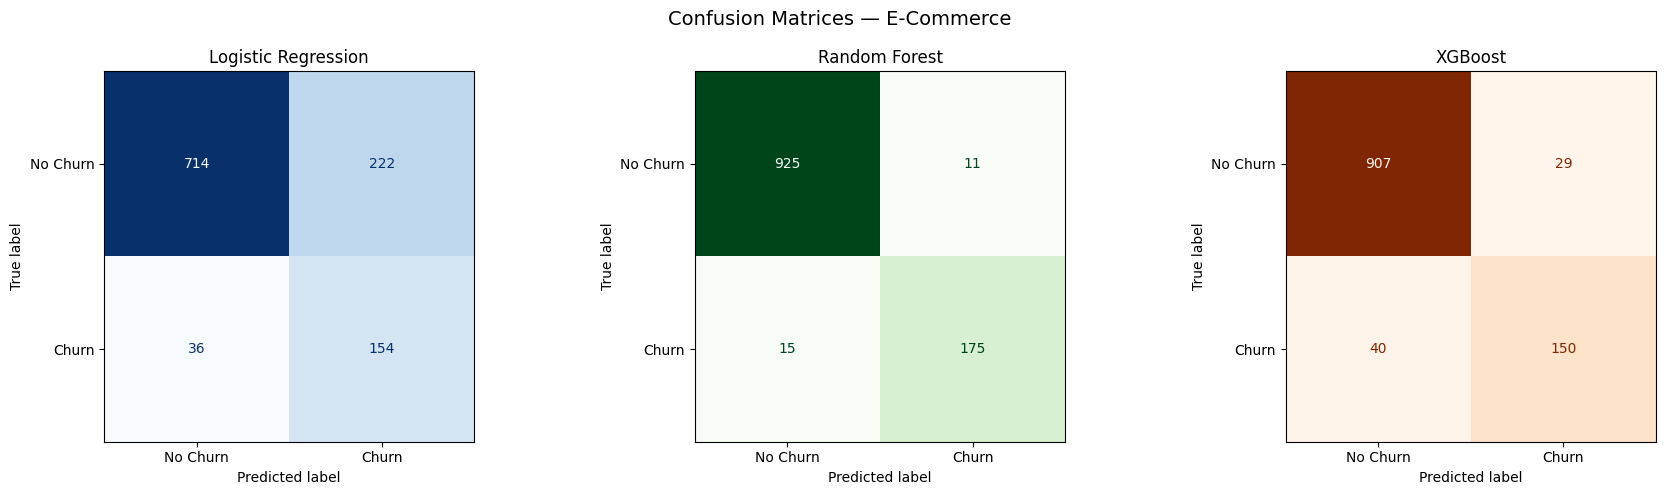

In [6]:
os.makedirs('outputs/plots/ecommerce', exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models_list = [
    (lr_model,  'Logistic Regression', 'Blues'),
    (rf_model,  'Random Forest',       'Greens'),
    (xgb_model, 'XGBoost',             'Oranges'),
]

for ax, (model, name, cmap) in zip(axes, models_list):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['No Churn','Churn']
    ).plot(ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(f'{name}')

plt.suptitle('Confusion Matrices — E-Commerce', fontsize=14)
plt.tight_layout()
plt.savefig('outputs/plots/ecommerce/07_confusion_matrices.png',
            bbox_inches='tight')
plt.show()

c:\Users\DELL\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
c:\Users\DELL\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
c:\Users\DELL\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


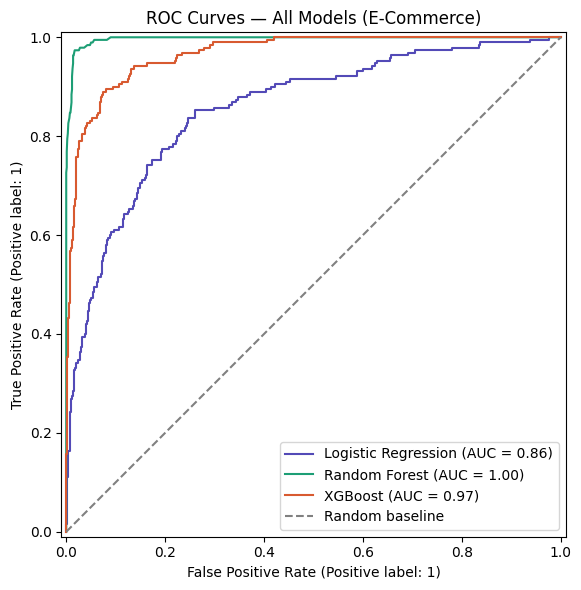

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))

colors = ['#534AB7','#1D9E75','#D85A30']
names  = ['Logistic Regression','Random Forest','XGBoost']

for model, name, color in zip(
    [lr_model, rf_model, xgb_model], names, colors
):
    proba = model.predict_proba(X_test)[:,1]
    RocCurveDisplay.from_predictions(
        y_test, proba, ax=ax,
        name=name, color=color
    )

ax.plot([0,1],[0,1],'--',color='gray',label='Random baseline')
ax.set_title('ROC Curves — All Models (E-Commerce)')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/plots/ecommerce/08_all_roc_curves.png',
            bbox_inches='tight')
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_22060\744152899.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\DELL\AppData\Local\Temp\ipykernel_22060\744152899.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


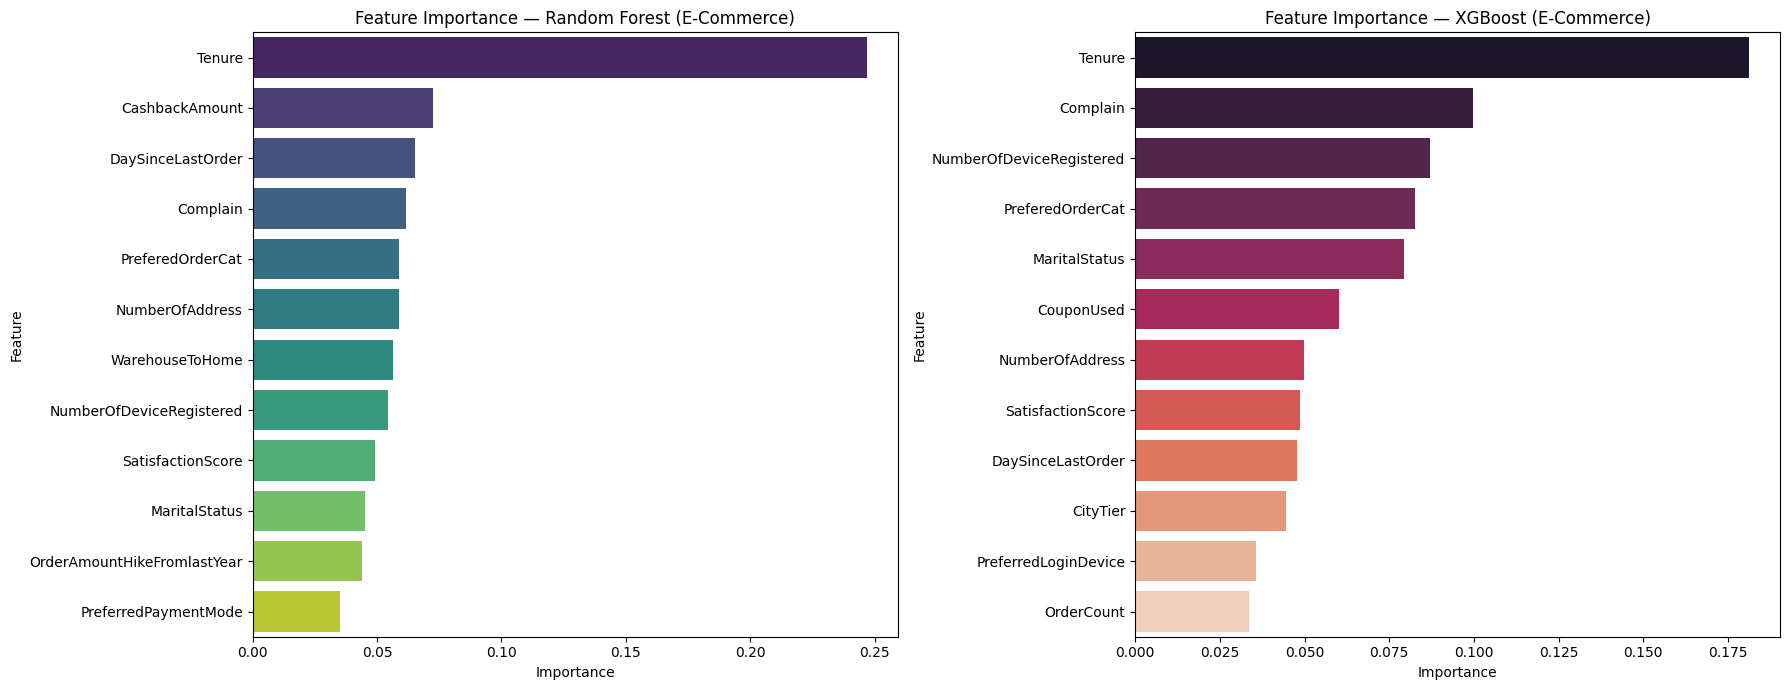


Top 5 features — Random Forest:
          Feature  RF_Importance
           Tenure       0.246821
   CashbackAmount       0.072487
DaySinceLastOrder       0.065140
         Complain       0.061447
 PreferedOrderCat       0.058760

Top 5 features — XGBoost:
                 Feature  XGB_Importance
                  Tenure        0.181306
                Complain        0.099855
NumberOfDeviceRegistered        0.087120
        PreferedOrderCat        0.082603
           MaritalStatus        0.079426


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, model, name, color in [
    (axes[0], rf_model,  'Random Forest', 'viridis'),
    (axes[1], xgb_model, 'XGBoost',       'rocket'),
]:
    importances = model.feature_importances_
    feat_df = pd.DataFrame({
        'Feature'   : feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False).head(12)

    sns.barplot(
        data=feat_df, x='Importance', y='Feature',
        palette=color, ax=ax
    )
    ax.set_title(f'Feature Importance — {name} (E-Commerce)')

plt.tight_layout()
plt.savefig('outputs/plots/ecommerce/09_feature_importance.png',
            bbox_inches='tight')
plt.show()

print("\nTop 5 features — Random Forest:")
rf_feat = pd.DataFrame({
    'Feature': feature_names,
    'RF_Importance': rf_model.feature_importances_
}).sort_values('RF_Importance', ascending=False)
print(rf_feat.head(5).to_string(index=False))

print("\nTop 5 features — XGBoost:")
xgb_feat = pd.DataFrame({
    'Feature': feature_names,
    'XGB_Importance': xgb_model.feature_importances_
}).sort_values('XGB_Importance', ascending=False)
print(xgb_feat.head(5).to_string(index=False))

In [9]:
# Load existing results
try:
    existing = pd.read_csv('outputs/results/telecom_results.csv')
except FileNotFoundError:
    existing = pd.DataFrame()

new_rows = pd.DataFrame([results_lr, results_rf, results_xgb])
updated = pd.concat([existing, new_rows], ignore_index=True)
updated.to_csv('outputs/results/all_results.csv', index=False)

print("All results so far:")
print(updated.to_string(index=False))

# Save models
joblib.dump(lr_model,  'outputs/lr_model_ecommerce.pkl')
joblib.dump(rf_model,  'outputs/rf_model_ecommerce.pkl')
joblib.dump(xgb_model, 'outputs/xgb_model_ecommerce.pkl')
print("\nAll 3 models saved to outputs/")

All results so far:
    Sector               Model  Accuracy  Precision  Recall     F1  ROC_AUC
   Telecom Logistic Regression    0.8055     0.6582  0.5561 0.6029   0.8421
   Telecom       Random Forest    0.7899     0.6291  0.5080 0.5621   0.8244
   Telecom             XGBoost    0.7935     0.6436  0.4973 0.5611   0.8401
E-Commerce Logistic Regression    0.7709     0.4096  0.8105 0.5442   0.8566
E-Commerce       Random Forest    0.9769     0.9409  0.9211 0.9309   0.9968
E-Commerce             XGBoost    0.9387     0.8380  0.7895 0.8130   0.9668

All 3 models saved to outputs/


In [10]:
all_results = pd.read_csv('outputs/results/all_results.csv')

print("Full results table:")
print(all_results.to_string(index=False))

print("\nBest model per sector:")
print("-"*50)
for sector in all_results['Sector'].unique():
    sector_df = all_results[all_results['Sector']==sector]
    best_idx  = sector_df['F1'].idxmax()
    best_row  = all_results.loc[best_idx]
    print(f"{sector:<15}: {best_row['Model']:<25} F1={best_row['F1']:.4f}")

print("\nF1 comparison — Telecom vs E-Commerce:")
pivot = all_results.pivot(
    index='Model', columns='Sector', values='F1'
).round(4)
print(pivot)

Full results table:
    Sector               Model  Accuracy  Precision  Recall     F1  ROC_AUC
   Telecom Logistic Regression    0.8055     0.6582  0.5561 0.6029   0.8421
   Telecom       Random Forest    0.7899     0.6291  0.5080 0.5621   0.8244
   Telecom             XGBoost    0.7935     0.6436  0.4973 0.5611   0.8401
E-Commerce Logistic Regression    0.7709     0.4096  0.8105 0.5442   0.8566
E-Commerce       Random Forest    0.9769     0.9409  0.9211 0.9309   0.9968
E-Commerce             XGBoost    0.9387     0.8380  0.7895 0.8130   0.9668

Best model per sector:
--------------------------------------------------
Telecom        : Logistic Regression       F1=0.6029
E-Commerce     : Random Forest             F1=0.9309

F1 comparison — Telecom vs E-Commerce:
Sector               E-Commerce  Telecom
Model                                   
Logistic Regression      0.5442   0.6029
Random Forest            0.9309   0.5621
XGBoost                  0.8130   0.5611


In [11]:
import joblib
import pandas as pd
import numpy as np

scaler = joblib.load('outputs/scaler_ecommerce.pkl')
feature_names = pd.read_csv(
    'outputs/ecommerce_feature_names.csv'
).squeeze().tolist()

print("Features:", feature_names)
print("Total features:", len(feature_names))

Features: ['Tenure', 'PreferredLoginDevice', 'CityTier', 'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']
Total features: 18


In [12]:
import joblib
joblib.dump(lr_model,  'outputs/lr_model_ecommerce.pkl')
joblib.dump(rf_model,  'outputs/rf_model_ecommerce.pkl')
joblib.dump(xgb_model, 'outputs/xgb_model_ecommerce.pkl')
print("Models saved:")
print("  outputs/lr_model_ecommerce.pkl")
print("  outputs/rf_model_ecommerce.pkl")
print("  outputs/xgb_model_ecommerce.pkl")

Models saved:
  outputs/lr_model_ecommerce.pkl
  outputs/rf_model_ecommerce.pkl
  outputs/xgb_model_ecommerce.pkl
